In [1]:
import pandas as pd
import geopandas as gpd 
import requests 
import json
from datetime import datetime
from io import StringIO
import csv
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from shapely import wkt
from scipy.spatial.distance import cdist

import pandas as pd
import geopandas as gpd 
import requests 
import json
from datetime import datetime
from io import StringIO
import csv
import time
import os
import airqualityandclimateAPI
import statsmodels.api as sm

from statsmodels.stats.outliers_influence \
     import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)
from linearmodels import PanelOLS
import numpy as np

In [2]:
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize)
from functools import partial
from sklearn.pipeline import Pipeline
# from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from ISLP.models import \
     (Stepwise,
      sklearn_selected,
      sklearn_selection_path)

In [3]:
import Analysis
from Analysis import model_4_lasso_panel

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:48: DtypeWarning: Columns (9,11,12,13,14,15,18,23,28,36,38,40,55,56,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,106) have mixed types. Specify dtype option on import or set low_memory=False.
  climatedata = pd.read_csv(climatedatapath)
/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:52: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  airqualitydata = pd.read_csv(airqualitydatapath)
/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:71: DtypeWarning: Columns (8,9,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  totaldf = pd.read_csv(totaldatapath)


In [4]:
import Final_LASSO
import Random_Forest 

In [5]:
totaldataframe = Analysis.totaldata()

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:89: DtypeWarning: Columns (8,9,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  totaldf = pd.read_csv(totaldatapath)


# LASSO

#### Final LASSO using PM2.5

In [6]:
finallassopm = Final_LASSO.final_LASSO(totaldataframe, pm=True)


Non-numeric columns remaining: []
NaNs in X: 0
Initiating Shuffle Split:
Fitting Hyper Parameter Pipeline:


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.390e+03, tolerance: 1.892e+02
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the s

Tuned alpha = 0.01295247137914592
Testing the Tuned Lasso with Cross Validation:
results saved
The non-zero coefficient estimates are:
                                        feature  coefficient
5                DailyMaximumDryBulbTemperature     1.714400
31                        CO2 Mass (short tons)     1.511161
30                        SO2 Mass (short tons)    -1.150008
37                                  sunrise_cos    -1.128472
4    DailyDepartureFromNormalAverageTemperature     1.084164
..                                          ...          ...
98         DailySustainedWindDirection_cos_lag2    -0.001576
108          DailyAverageWindDirection_sin_lag2    -0.001514
65           DailyAverageWindDirection_sin_lag1    -0.000828
96              DailyPeakWindDirection_cos_lag2    -0.000145
161                                   YEAR_lag3    -0.000033

[80 rows x 2 columns]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.707e+03, tolerance: 2.916e+02
  model = cd_fast.enet_coordinate_descent(


In [90]:
finallassofeaturespm = finallassopm[2]
finallassofeaturespm

['DailyMaximumDryBulbTemperature',
 'CO2 Mass (short tons)',
 'SO2 Mass (short tons)',
 'sunrise_cos',
 'DailyDepartureFromNormalAverageTemperature',
 'Sunrise_lag3',
 'AQlatitude',
 'DailyMinimumDryBulbTemperature_lag3',
 'sunrise_cos_lag1',
 'sunrise_cos_lag2',
 'sunrise_cos_lag3',
 'CO2 Mass (short tons)_lag3',
 'NUM_READS',
 'DailyMinimumDryBulbTemperature',
 'BUS_COUNT',
 'Sunrise',
 'sunset_cos',
 'DailyPeakWindSpeed_lag3',
 'NOx Mass (short tons)_lag3',
 'DailySustainedWindDirection_cos']

Correlation matrix for selected variables from PM LASSO: 

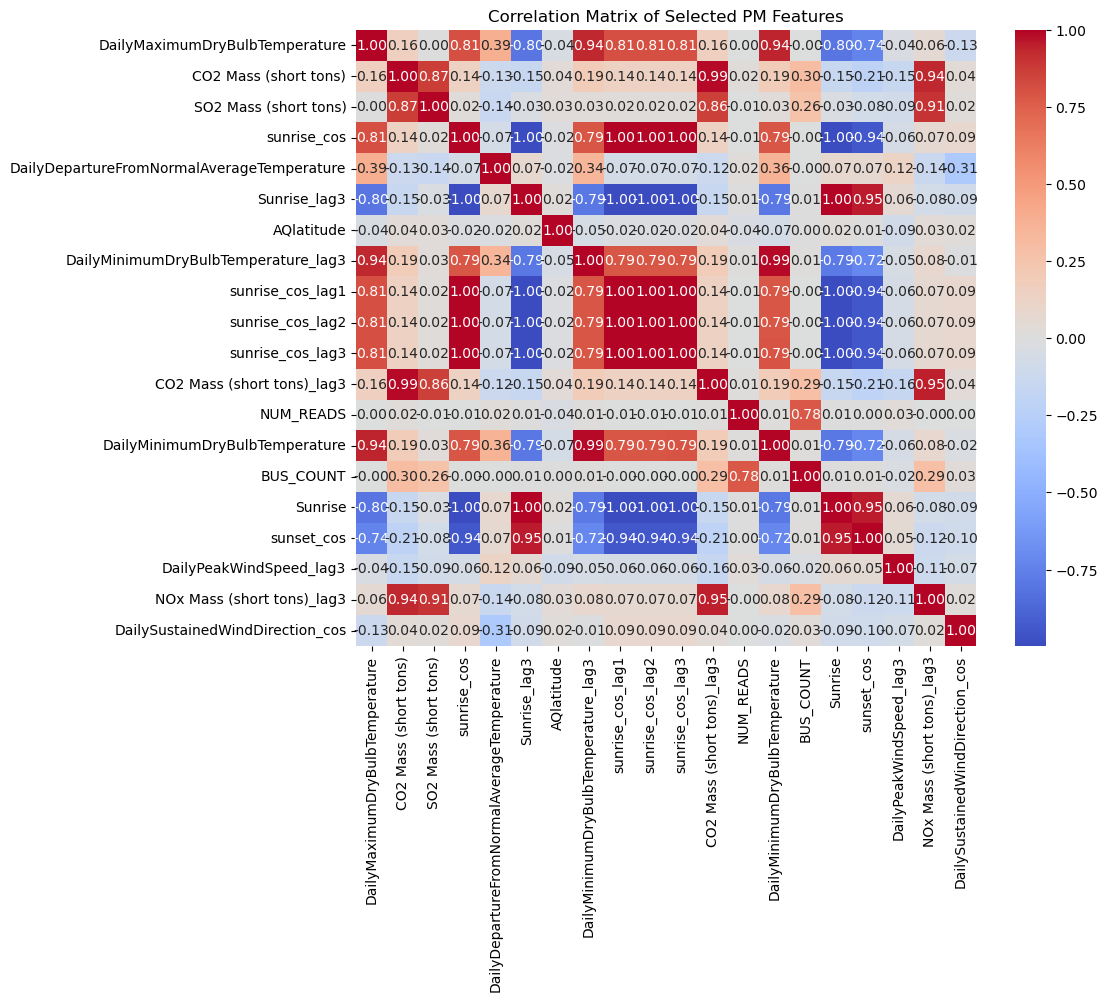

In [94]:
pmvars = totaldataframe[finallassofeaturespm]

pmvarscorr = pmvars.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(pmvarscorr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Selected PM Features')
plt.show()

#### Final LASSO using AQI

In [95]:
finallassoaqi = Final_LASSO.final_LASSO(totaldataframe, pm=False)
finallassofeaturesaqi = finallassoaqi[2]
finallassofeaturesaqi


Non-numeric columns remaining: []
NaNs in X: 0
Initiating Shuffle Split:
Fitting Hyper Parameter Pipeline:


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.511e+03, tolerance: 1.387e+03
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the s

Tuned alpha = 0.050032627590710296
Testing the Tuned Lasso with Cross Validation:
results saved
The non-zero coefficient estimates are:
                                        feature  coefficient
5                DailyMaximumDryBulbTemperature     6.854914
4    DailyDepartureFromNormalAverageTemperature     4.111347
132         DailyMinimumDryBulbTemperature_lag3    -4.023209
31                        CO2 Mass (short tons)     3.984038
27                                   AQlatitude    -3.782849
..                                          ...          ...
96              DailyPeakWindDirection_cos_lag2    -0.005637
95              DailyPeakWindDirection_sin_lag2     0.004634
48                      DailyPrecipitation_lag1     0.002855
36                                  sunrise_sin    -0.001369
16                 DailyAverageAltimeterSetting     0.001283

[65 rows x 2 columns]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.294e+04, tolerance: 2.166e+03
  model = cd_fast.enet_coordinate_descent(


['DailyMaximumDryBulbTemperature',
 'DailyDepartureFromNormalAverageTemperature',
 'DailyMinimumDryBulbTemperature_lag3',
 'CO2 Mass (short tons)',
 'AQlatitude',
 'sunrise_cos',
 'DailyMinimumDryBulbTemperature',
 'sunset_cos_lag3',
 'SO2 Mass (short tons)',
 'NUM_READS',
 'BUS_COUNT',
 'DailySustainedWindDirection_cos',
 'sunrise_cos_lag1',
 'DailyPeakWindSpeed_lag3',
 'sunset_cos',
 'CO2 Mass (short tons)_lag3',
 'sunrise_cos_lag2',
 'AQlongitude',
 'NOx Mass (short tons)_lag3',
 'DailyPeakWindSpeed']

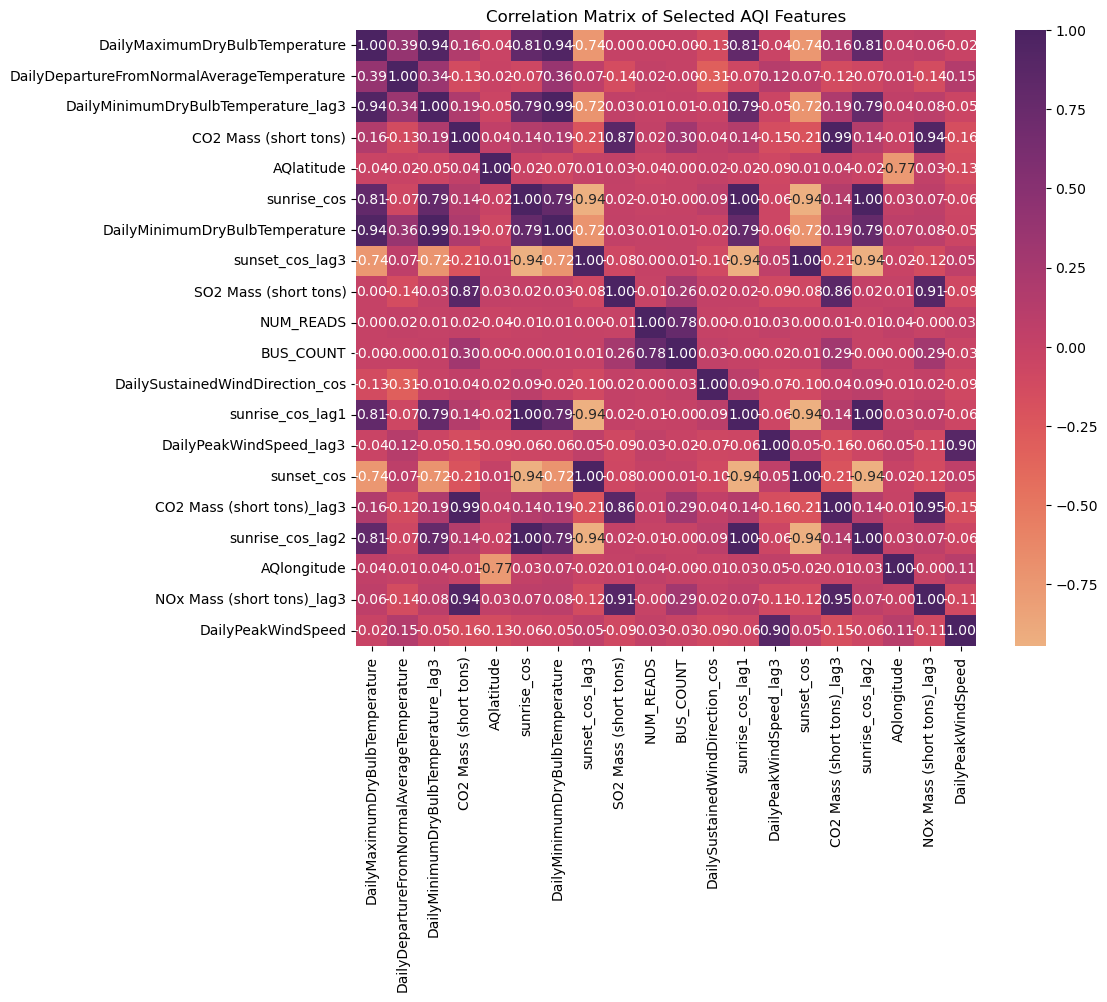

In [96]:
aqivars = totaldataframe[finallassofeaturesaqi]

aqivarscorr = aqivars.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(aqivarscorr, annot=True, cmap='flare', fmt='.2f')
plt.title('Correlation Matrix of Selected AQI Features')
plt.show()

In [11]:
xmatrixpm = finallassofeaturespm
xmatrixaqi = finallassofeaturesaqi

fe = ['CLIMATE_STATION_NAME','YEAR']
fe2 = ['CLIMATE_STATION_NAME','YEAR','AQ_STATION_NAME']

y_pm = ['arithmetic_mean']
y_aqi = ['aqi']

# xvars = ['Number', 'Capacity']
xvarsnum = ['Number']
xvarscap = ['Capacity']

## X variables using the PM results: 
x_pm_num = xvarsnum + xmatrixpm
x_pm_cap = xvarscap + xmatrixpm

## X variables using the AQIQ results:
x_aqi_num = xvarsnum + xmatrixaqi
x_aqi_cap = xvarscap + xmatrixaqi

# totalcols = x+y

OLS LASSO PM using Number of gens:

In [12]:
OLS_PM_NUM = model_4_lasso_panel(totaldataframe, x_pm_num, y_pm, fe)
print(OLS_PM_NUM)

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:817: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunrise_cos_lag1, sunrise_cos_lag2, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:        arithmetic_mean   R-squared:                        0.1407
Estimator:                   PanelOLS   R-squared (Between):             -0.9453
No. Observations:               72978   R-squared (Within):               0.1431
Date:                Thu, Apr 30 2026   R-squared (Overall):              0.1421
Time:                        22:06:56   Log-likelihood                -2.316e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      746.35
Entities:                           2   P-value                           0.0000
Avg Obs:                    3.649e+04   Distribution:                F(16,72951)
Min Obs:                    3.575e+04                                           
Max Obs:                    3.723e+04   F-statistic (robust):          1.508e+16
                            

OLS LASSO PM using Daily sum of added gen capacity 

In [13]:
OLS_PM_CAP = model_4_lasso_panel(totaldataframe, x_pm_cap, y_pm , fe)
print(OLS_PM_CAP)

                          PanelOLS Estimation Summary                           
Dep. Variable:        arithmetic_mean   R-squared:                        0.1407
Estimator:                   PanelOLS   R-squared (Between):             -0.9478
No. Observations:               72978   R-squared (Within):               0.1432
Date:                Thu, Apr 30 2026   R-squared (Overall):              0.1422
Time:                        22:07:02   Log-likelihood                -2.316e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      746.57
Entities:                           2   P-value                           0.0000
Avg Obs:                    3.649e+04   Distribution:                F(16,72951)
Min Obs:                    3.575e+04                                           
Max Obs:                    3.723e+04   F-statistic (robust):         -2.878e+17
                            

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:817: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunrise_cos_lag1, sunrise_cos_lag2, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


OLS AQI using Number:

In [14]:
OLS_AQI_NUM = model_4_lasso_panel(totaldataframe, x_aqi_num, y_aqi, fe)
print(OLS_AQI_NUM)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    aqi   R-squared:                        0.2632
Estimator:                   PanelOLS   R-squared (Between):              0.3988
No. Observations:               72978   R-squared (Within):               0.2559
Date:                Thu, Apr 30 2026   R-squared (Overall):              0.2564
Time:                        22:07:12   Log-likelihood                -2.992e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1629.1
Entities:                           2   P-value                           0.0000
Avg Obs:                    3.649e+04   Distribution:                F(16,72951)
Min Obs:                    3.575e+04                                           
Max Obs:                    3.723e+04   F-statistic (robust):          2.806e+16
                            

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:817: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunset_cos_lag3, sunrise_cos_lag1, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


OLS AQI using Capacity:


In [15]:
OLS_AQI_CAP = model_4_lasso_panel(totaldataframe, x_aqi_cap, y_aqi, fe)
print(OLS_AQI_CAP) 

                          PanelOLS Estimation Summary                           
Dep. Variable:                    aqi   R-squared:                        0.2633
Estimator:                   PanelOLS   R-squared (Between):              0.3984
No. Observations:               72978   R-squared (Within):               0.2562
Date:                Thu, Apr 30 2026   R-squared (Overall):              0.2566
Time:                        22:07:17   Log-likelihood                -2.992e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1629.9
Entities:                           2   P-value                           0.0000
Avg Obs:                    3.649e+04   Distribution:                F(16,72951)
Min Obs:                    3.575e+04                                           
Max Obs:                    3.723e+04   F-statistic (robust):         -3.814e+18
                            

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:817: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunset_cos_lag3, sunrise_cos_lag1, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


# AQ Station Fixed Effects 

OLS AQI using Num and AQ STATION FE:

In [16]:
aq_station_dummies = pd.get_dummies(totaldataframe['AQ_STATION_NAME'],prefix='AQ_STATION_NAME',drop_first = True)
totaldataframe2 = pd.concat([totaldataframe, aq_station_dummies], axis=1)

x_aqi_num_aq = x_aqi_num + list(aq_station_dummies.columns)
x_aqi_cap_aq = x_aqi_cap + list(aq_station_dummies.columns)

print(len(list(aq_station_dummies.columns)))

print(len(totaldataframe['AQ_STATION_NAME'].unique()))



11
12


In [17]:
OLS_AQI_NUM_AQ = model_4_lasso_panel(totaldataframe2, x_aqi_num_aq, y_aqi, fe)
print(OLS_AQI_NUM_AQ)

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:817: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunrise_cos_lag1, sunset_cos, AQ_STATION_NAME_REGIONAL OFFICE BUILDING, AQ_STATION_NAME_VILLAGE HALL, AQ_STATION_NAME_WASHINGTON HS

  results = model.fit(cov_type='clustered', cluster_entity=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:                    aqi   R-squared:                        0.2765
Estimator:                   PanelOLS   R-squared (Between):          -5.149e+04
No. Observations:               72978   R-squared (Within):               0.2746
Date:                Thu, Apr 30 2026   R-squared (Overall):             -171.70
Time:                        22:07:22   Log-likelihood                -2.985e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1115.3
Entities:                           2   P-value                           0.0000
Avg Obs:                    3.649e+04   Distribution:                F(25,72942)
Min Obs:                    3.575e+04                                           
Max Obs:                    3.723e+04   F-statistic (robust):         -6.395e+15
                            

Note that adding the aq-station fixed effects increased the coefficient on the Number of generators and also increased the R-squared representing the model's fit 

OLS AQI using Capacity and AQ STATION FE:

In [18]:
OLS_AQI_CAP_AQ = model_4_lasso_panel(totaldataframe2, x_aqi_cap_aq, y_aqi, fe)
print(OLS_AQI_CAP_AQ)

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:817: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunrise_cos_lag1, sunset_cos, AQ_STATION_NAME_REGIONAL OFFICE BUILDING, AQ_STATION_NAME_VILLAGE HALL, AQ_STATION_NAME_WASHINGTON HS

  results = model.fit(cov_type='clustered', cluster_entity=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:                    aqi   R-squared:                        0.2766
Estimator:                   PanelOLS   R-squared (Between):          -5.161e+04
No. Observations:               72978   R-squared (Within):               0.2748
Date:                Thu, Apr 30 2026   R-squared (Overall):             -172.09
Time:                        22:07:23   Log-likelihood                -2.985e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1115.8
Entities:                           2   P-value                           0.0000
Avg Obs:                    3.649e+04   Distribution:                F(25,72942)
Min Obs:                    3.575e+04                                           
Max Obs:                    3.723e+04   F-statistic (robust):         -3.172e+17
                            

# Random Forest ________________________

Random Forest using PM:

In [19]:
random_forest_pm = Random_Forest.random_forest(totaldataframe, pm=True)

Number of NaNs in X: 0
Preprocessing setup complete.
Fitting the Grid Search for RF hyperparameter tuning...
100
Fitting the RF model
(51082, 168)
                                             feature  importance
112                       SO2 Mass (short tons)_lag2    0.014460
139                  DailyPeakWindDirection_cos_lag3    0.013461
4         DailyDepartureFromNormalAverageTemperature    0.013183
80                                         DATE_lag2    0.012534
130  DailyDepartureFromNormalAverageTemperature_lag3    0.011551
114                       NOx Mass (short tons)_lag2    0.011299
156                       CO2 Mass (short tons)_lag3    0.010971
98              DailySustainedWindDirection_cos_lag2    0.010831
36                                       sunrise_sin    0.010700
10                                           Sunrise    0.010583
29                                  Gross Load (MWh)    0.010549
44   DailyDepartureFromNormalAverageTemperature_lag1    0.010475
0       

In [20]:
random_forest_pm[3].head(20)

,feature,importance
112,SO2 Mass (short tons)_lag2,0.014460
139,DailyPeakWindDirection_cos_lag3,0.013461
4,DailyDepartureFromNormalAverageTemperature,0.013183
80,DATE_lag2,0.012534
130,DailyDepartureFromNormalAverageTemperature_lag3,0.011551
114,NOx Mass (short tons)_lag2,0.011299
156,CO2 Mass (short tons)_lag3,0.010971
98,DailySustainedWindDirection_cos_lag2,0.010831
36,sunrise_sin,0.010700
10,Sunrise,0.010583


Random Forest using AQI:


In [21]:
random_forest_aqi = Random_Forest.random_forest(totaldataframe, pm=False)


Number of NaNs in X: 0
Preprocessing setup complete.
Fitting the Grid Search for RF hyperparameter tuning...
100
Fitting the RF model
(51082, 168)
                                             feature  importance
4         DailyDepartureFromNormalAverageTemperature    0.016058
44   DailyDepartureFromNormalAverageTemperature_lag1    0.015018
87   DailyDepartureFromNormalAverageTemperature_lag2    0.013881
53                   DailyPeakWindDirection_cos_lag1    0.013785
130  DailyDepartureFromNormalAverageTemperature_lag3    0.013110
98              DailySustainedWindDirection_cos_lag2    0.012847
139                  DailyPeakWindDirection_cos_lag3    0.012210
96                   DailyPeakWindDirection_cos_lag2    0.011879
55              DailySustainedWindDirection_cos_lag1    0.011819
15                   DailySustainedWindDirection_cos    0.011058
141             DailySustainedWindDirection_cos_lag3    0.010765
88               DailyMaximumDryBulbTemperature_lag2    0.010588
80      

In [22]:
random_forest_aqi[3].head(20)

,feature,importance
4,DailyDepartureFromNormalAverageTemperature,0.016058
44,DailyDepartureFromNormalAverageTemperature_lag1,0.015018
87,DailyDepartureFromNormalAverageTemperature_lag2,0.013881
53,DailyPeakWindDirection_cos_lag1,0.013785
130,DailyDepartureFromNormalAverageTemperature_lag3,0.013110
98,DailySustainedWindDirection_cos_lag2,0.012847
139,DailyPeakWindDirection_cos_lag3,0.012210
96,DailyPeakWindDirection_cos_lag2,0.011879
55,DailySustainedWindDirection_cos_lag1,0.011819
15,DailySustainedWindDirection_cos,0.011058


# Making Tables

In [23]:
import os
from stargazer.stargazer import Stargazer, LineLocation


Table 1. LASSO OLS results for PM mean on LASSO Selected vars and Renewables

In [24]:
def sig_vars(model_name):
    p_values = model_name.pvalues

    # Filter for variables where p < 0.05 (or your chosen threshold)
    significant_vars = p_values[p_values < 0.05].index.tolist()

    # If the 'intercept' or 'const' is significant but you want to hide it, 
    # you can remove it from the list manually:
    if 'const' in significant_vars:
        significant_vars.remove('const')
    
    return significant_vars

In [25]:
rename_dict = {
    "DailyAverageDryBulbTemperature":      "Daily Average Dry Bulb Temperature",
    "DailyAverageDewPointTemperature":  "Daily Average Dew Point Temperature",
    "DailyAveragePrecipitation": "Daily Average Precipitation",
    "DailyAveragePressureChange":     "Daily Average Pressure Change",
    "DailyAverageRelativeHumidity":     "Daily Average Relative Humidity",
    "DailyAverageSeaLevelPressure":     "Daily Average Sea Level Pressure",
    "DailyAverageStationPressure":     "Daily Average Station Pressure",
    "DailyAverageWetBulbTemperature":     "Daily Average Wet Bulb Temperature",
    "DailyAverageWindDirection_cos":     "Daily Average Wind Direction (cosine)",
    "DailyAverageWindDirection_sin":     "Daily Average Wind Direction (sine)",
    "DailyAverageWindGustSpeed":     "Daily Average Wind Gust Speed",
    "DailyAverageWindSpeed":     "Daily Average Wind Speed",
    "DailyDepartureFromNormalAverageTemperature":     "Daily Departure from Normal Average Temperature",
    "DailyMaximumDryBulbTemperature":     "Daily Maximum Dry Bulb Temperature",
    "DailyMinimumDryBulbTemperature":     "Daily Minimum Dry Bulb Temperature",
    "DailyPeakWindDirection_cos":     "Daily Peak Wind Direction (cosine)",
    "DailyPeakWindSpeed":     "Daily Peak Wind Speed",
    "DailyPrecipitation":     "Daily Precipitation",
    "DailySustainedWindDirection_cos":     "Daily Sustained Wind Direction (cosine)",
    "DailySustainedWindDirection_sin":     "Daily Sustained Wind Direction (sine)",
    "DailySustainedWindSpeed":     "Daily Sustained Wind Speed",
    "Number": "Number of Renewable Generators Added",
    "CO2 Mass (short tons)_lag3": "CO2 Mass (short tons) Lagged 3 Days",
    "NUM_READS": "Number of Traffic GPS Signals",
    "BUS_COUNT": "Number of Buses",
    "DailyPeakWindSpeed_lag3": "Daily Peak Wind Speed Lagged 3 Days",
    "NOx Mass (short tons)_lag3	": "NOx Mass (short tons) Lagged 3 Days",
    "DailyMinimumDryBulbTemperature_lag3	": "Daily Minimum Dry Bulb Temperature Lagged 3 Days",
    "AQlatitude": "AQ Station Latitude",
    "DailyPeakWindDirection_sin": "Daily Peak Wind Direction (sine)",
    "AQlongitude": "AQ Station Longitude",
    "sunrise_cos_lag2": "Cosine of Sunrise Time Lagged 2 Days",
    "DailyMinimumDryBulbTemperature_lag3": "Daily Minimum Dry Bulb Temperature Lagged 3 Days"
    
    

}

In [26]:

star1 = Stargazer([OLS_PM_NUM])

star1.title("Table 1. Average PM 2.5 on Number of Generators and LASSO-Selected Variables (LASSO to Panel OLS)")
star1.custom_columns(["LASSO 2"], [1])
star1.covariate_order(sig_vars(OLS_PM_NUM))  # Only include significant variables in the table
star1.dependent_variable_name("Average PM 2.5 (µg/m³)")
star1.rename_covariates(rename_dict)
star1.significance_levels([0.1, 0.05, 0.01])   # * p<0.1, ** p<0.05, *** p<0.01
star1.show_degrees_of_freedom(False)

star1.add_line(
    "Standard errors",
    ["Robust (HC1)"],
    LineLocation.FOOTER_TOP,
)
star1.add_custom_notes([
    "Heteroskedasticity-robust standard errors in parentheses.",
    "Fixed effects for Climate Station and Year included",
])

star1


Table 2: Results for PM 2.5 on Capacity and LASSO-selected variables:

In [27]:

star2 = Stargazer([OLS_PM_CAP])

star2.title("Table 2. Average PM 2.5 on Added Capacity and LASSO-Selected Variables (LASSO to Panel OLS)")
star2.custom_columns(["LASSO 2"], [1])
star2.covariate_order(sig_vars(OLS_PM_CAP))  # Only include significant variables in the table
star2.dependent_variable_name("Average PM 2.5 (µg/m³)")
star2.rename_covariates(rename_dict)
star2.significance_levels([0.1, 0.05, 0.01])   # * p<0.1, ** p<0.05, *** p<0.01
star2.show_degrees_of_freedom(False)

star2.add_line(
    "Standard errors",
    ["Robust (HC1)"],
    LineLocation.FOOTER_TOP,
)
star2.add_custom_notes([
    "Heteroskedasticity-robust standard errors in parentheses.",
    "Fixed effects for Climate Station and Year included",
])

star2

LASSO 3: AQI on Number of Renewables 

In [28]:
star3 = Stargazer([OLS_AQI_NUM])

star3.title("Table 3. AQI on Number of Generators and LASSO-Selected Variables (LASSO to Panel OLS)")
star3.custom_columns(["LASSO 3"], [1])
star3.covariate_order(sig_vars(OLS_AQI_NUM))  # Only include significant variables in the table
star3.dependent_variable_name("Average AQI")
star3.rename_covariates(rename_dict)
star3.significance_levels([0.1, 0.05, 0.01])   # * p<0.1, ** p<0.05, *** p<0.01
star3.show_degrees_of_freedom(False)

star3.add_line(
    "Standard errors",
    ["Robust (HC1)"],
    LineLocation.FOOTER_TOP,
)
star3.add_custom_notes([
    "Heteroskedasticity-robust standard errors in parentheses.",
    "Fixed effects for Climate Station and Year included",
])

star3

LASSO 4: AQI on Daily Capacity Added and LASSO-selected Variables:

In [29]:
star4 = Stargazer([OLS_AQI_CAP])

star4.title("<b>Table 4. AQI on Capacity and LASSO-Selected Variables (LASSO to Panel OLS)</b>")
star4.custom_columns(["LASSO 4"], [1])
star4.covariate_order(sig_vars(OLS_AQI_CAP))  # Only include significant variables in the table
star4.dependent_variable_name("Average AQI")
star4.rename_covariates(rename_dict)
star4.significance_levels([0.1, 0.05, 0.01])   # * p<0.1, ** p<0.05, *** p<0.01
star4.show_degrees_of_freedom(False)

star4.add_line(
    "Standard errors",
    ["Robust (HC1)"],
    LineLocation.FOOTER_TOP,
)
star4.add_custom_notes([
    "Heteroskedasticity-robust standard errors in parentheses.",
    "Fixed effects for Climate Station and Year included",
])

star4

In [30]:
#Saving tables from Panel OLS regressions for Regression Model I:

dir = '/Users/griffinberonio/Documents/AAE 724/Tables'
i = 0
for table in [star1, star2, star3, star4]:
    i += 1
    table_name = f"LASSO_{i}"
    html_path = os.path.join(dir, f"{table_name}.html")
    with open(html_path, 'w') as f:
        f.write(table.render_html())


# Random Forest Tables 

In [31]:
rf_aqi = random_forest_aqi[3].head(20).reset_index(drop=True)
# rf_aqi = rf_aqi.drop(['Index'])
rf_aqi['importance'] = rf_aqi['importance'].round(3)
rf_aqi

,feature,importance
0,DailyDepartureFromNormalAverageTemperature,0.016
1,DailyDepartureFromNormalAverageTemperature_lag1,0.015
2,DailyDepartureFromNormalAverageTemperature_lag2,0.014
3,DailyPeakWindDirection_cos_lag1,0.014
4,DailyDepartureFromNormalAverageTemperature_lag3,0.013
5,DailySustainedWindDirection_cos_lag2,0.013
6,DailyPeakWindDirection_cos_lag3,0.012
7,DailyPeakWindDirection_cos_lag2,0.012
8,DailySustainedWindDirection_cos_lag1,0.012
9,DailySustainedWindDirection_cos,0.011


In [32]:
rf_pm = random_forest_pm[3].head(20).reset_index(drop=True)
rf_pm['importance'] = rf_pm['importance'].round(3)
rf_pm

,feature,importance
0,SO2 Mass (short tons)_lag2,0.014
1,DailyPeakWindDirection_cos_lag3,0.013
2,DailyDepartureFromNormalAverageTemperature,0.013
3,DATE_lag2,0.013
4,DailyDepartureFromNormalAverageTemperature_lag3,0.012
5,NOx Mass (short tons)_lag2,0.011
6,CO2 Mass (short tons)_lag3,0.011
7,DailySustainedWindDirection_cos_lag2,0.011
8,sunrise_sin,0.011
9,Sunrise,0.011


In [33]:
dir = '/Users/griffinberonio/Documents/AAE 724/Tables'
i = 0
lis = [rf_aqi, rf_pm]
for table in lis:
    i += 1
    table_name = f"Random_Forest_Features_{i}"
    tex_path = os.path.join(dir, f"{table_name}.tex")
    with open(tex_path, 'w') as f:
        f.write(table.to_latex())

In [34]:
# Top coefficient dot and whisker plot for PM 2.5 on number of generators added:
OLS_PM_NUM.conf_int().head()

,lower,upper
Number,-0.001199,-0.000738
DailyMaximumDryBulbTemperature,0.073507,0.180416
CO2 Mass (short tons),0.000028,0.000032
SO2 Mass (short tons),-0.016081,-0.014890
DailyDepartureFromNormalAverageTemperature,0.227416,0.361892


In [35]:

paramseries = OLS_PM_NUM.params.head()
# Use confidence intervals to calculate error bars for the top 5 parameters:

conf5 = OLS_PM_NUM.conf_int().head()
error_series = paramseries - conf5['lower']
error_series

coef_df = pd.DataFrame({'coef': paramseries,
                        'err': error_series,
                        'varname': paramseries.index
                       })
coef_df

rename_dict = {"Number": "Number of Renewables",
               "DailyMaximumDryBulbTemperature": "Daily Max Temp",
               "DailyMinimumDryBulbTemperature": "Daily Min Temp",
               "DailyDepartureFromNormalAverageTemperature": "Departure from Normal Temp"}
coef_df['varname'] = coef_df['varname'].map(rename_dict).fillna(coef_df['varname'])
coef_df

,coef,err,varname
Number,-0.000969,0.000231,Number of Renewables
DailyMaximumDryBulbTemperature,0.126961,0.053454,Daily Max Temp
CO2 Mass (short tons),0.000030,0.000002,CO2 Mass (short tons)
SO2 Mass (short tons),-0.015485,0.000595,SO2 Mass (short tons)
DailyDepartureFromNormalAverageTemperature,0.294654,0.067238,Departure from Normal Temp


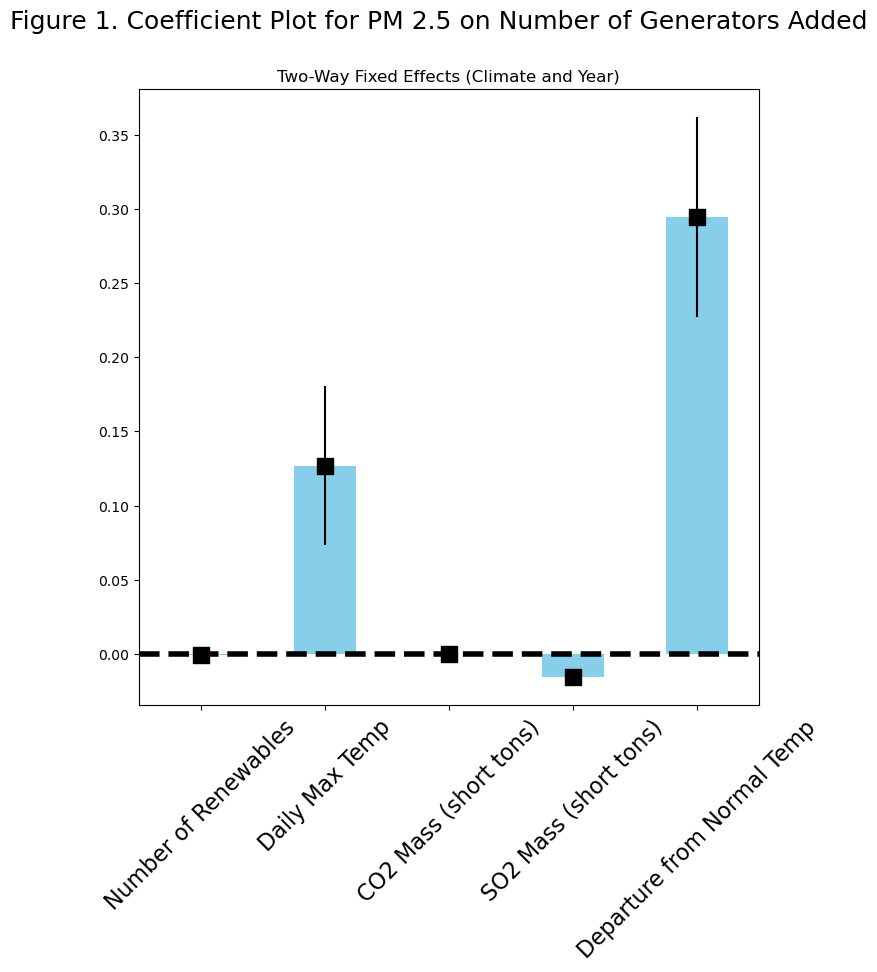

In [36]:
fig, ax = plt.subplots(figsize=(8, 8))
coef_df.plot(x='varname', y='coef', kind='bar', 
             ax=ax, color='skyblue', 
             yerr='err', legend=False)
ax.set_ylabel('')
ax.set_xlabel('')
ax.scatter(x=np.arange(coef_df.shape[0]), 
           marker='s', s=120, 
           y=coef_df['coef'], color='black')
ax.axhline(y=0, linestyle='--', color='black', linewidth=4)
_ = ax.set_xticklabels(coef_df['varname'],
                       rotation=45, fontsize=16)

plt.suptitle("Figure 1. Coefficient Plot for PM 2.5 on Number of Generators Added", fontsize=18)
ax.set_title("Two-Way Fixed Effects (Climate and Year)")

fs = 16
# ax.annotate('Control', xy=(0.3, -0.2), xytext=(0.3, -0.3), 
#             xycoords='axes fraction', 
#             textcoords='axes fraction', 
#             fontsize=fs, ha='center', va='bottom',
#             bbox=dict(boxstyle='square', fc='white', ec='black'),
#             arrowprops=dict(arrowstyle='-[, widthB=6.5, lengthB=1.2', lw=2.0, color='black'))

# _ = ax.annotate('Study', xy=(0.8, -0.2), xytext=(0.8, -0.3), 
#                  xycoords='axes fraction', 
#                  textcoords='axes fraction', 
#                  fontsize=fs, ha='center', va='bottom',
#                  bbox=dict(boxstyle='square', fc='white', ec='black'),
#                  arrowprops=dict(arrowstyle='-[, widthB=3.5, lengthB=1.2', lw=2.0, color='black'))

In [37]:
# AQI on Capacity Dot and whisker plot:
OLS_AQI_CAP

Dep. Variable:,aqi,R-squared:,0.2633
Estimator:,PanelOLS,R-squared (Between):,0.3984
No. Observations:,72978,R-squared (Within):,0.2562
Date:,"Thu, Apr 30 2026",R-squared (Overall):,0.2566
Time:,22:07:17,Log-likelihood,-2.992e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,1629.9
Entities:,2,P-value,0.0000
Avg Obs:,3.649e+04,Distribution:,"F(16,72951)"
Min Obs:,3.575e+04,,
Max Obs:,3.723e+04,F-statistic (robust):,-3.814e+18


In [38]:
OLS_AQI_CAP
includevars = ["Capacity", "AQlatitude", "DailySustainedWindDirection_cos",  "DailyPeakWindSpeed_lag3", "DailyPeakWindDirection_sin"]

paramseries_aqi = OLS_AQI_CAP.params[includevars]
conf_aqi = OLS_AQI_CAP.conf_int().loc[includevars]
error_series_aqi = paramseries_aqi - conf_aqi['lower']

coef_df = pd.DataFrame({'coef': paramseries_aqi,
                        'err': error_series_aqi,
                        'varname': paramseries_aqi.index
                       })
coef_df

rename_dict = {
               "AQlatitude": "Air Quality Station Latitude",
               "DailySustainedWindDirection_cos": "Daily Sustained Wind Direction (Cosine)",
               "DailyPeakWindSpeed_lag3": "Daily Peak Wind Speed (Lag 3)",
               "DailyPeakWindDirection_sin": "Daily Peak Wind Direction (Sine)",
               "DailyDepartureFromNormalAverageTemperature": "Departure from Normal Temp"}
coef_df['varname'] = coef_df['varname'].map(rename_dict).fillna(coef_df['varname'])
coef_df


,coef,err,varname
Capacity,-0.483811,0.158114,Capacity
AQlatitude,-20.852089,13.312088,Air Quality Station Latitude
DailySustainedWindDirection_cos,-4.604747,0.104836,Daily Sustained Wind Direction (Cosine)
DailyPeakWindSpeed_lag3,-0.373871,0.067099,Daily Peak Wind Speed (Lag 3)
DailyPeakWindDirection_sin,1.517853,0.714503,Daily Peak Wind Direction (Sine)


Text(0.5, 1.0, 'Figure 2. AQI on Renewable Capacity')

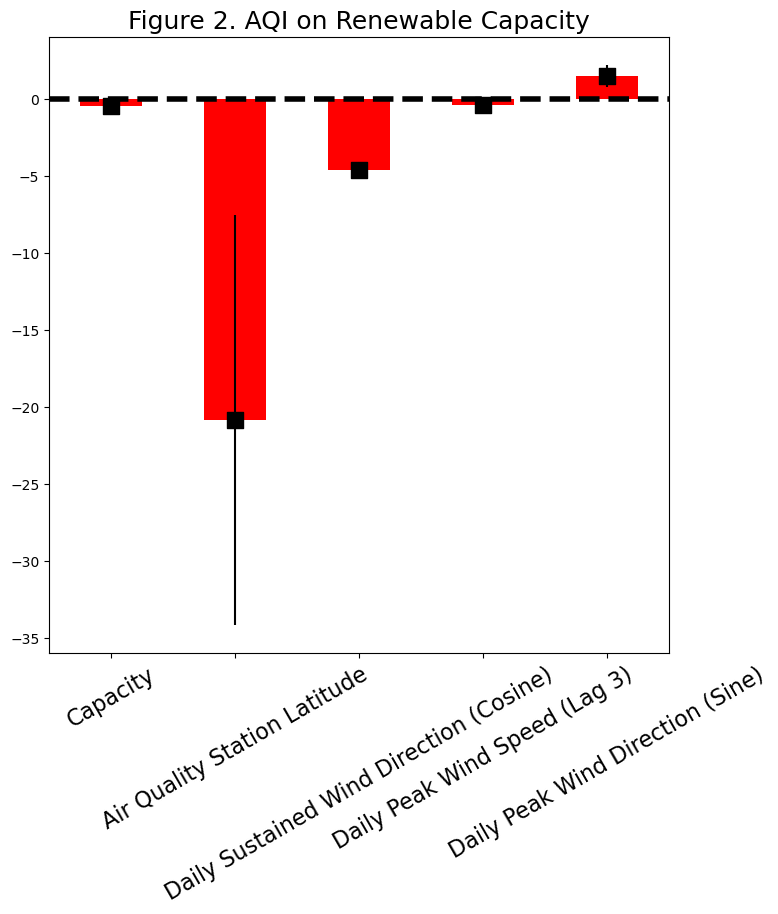

In [39]:
fig, ax = plt.subplots(figsize=(8, 8))
coef_df.plot(x='varname', y='coef', kind='bar', 
             ax=ax, color='red', 
             yerr='err', legend=False)
ax.set_ylabel('')
ax.set_xlabel('')
ax.scatter(x=np.arange(coef_df.shape[0]), 
           marker='s', s=120, 
           y=coef_df['coef'], color='black')
ax.axhline(y=0, linestyle='--', color='black', linewidth=4)
_ = ax.set_xticklabels(coef_df['varname'],
                       rotation=30, fontsize=16)

ax.set_title("Figure 2. AQI on Renewable Capacity", fontsize=18)


# Combined Regression Output for PM Regressions:

In [40]:
m1 = OLS_PM_NUM
m2 = OLS_PM_CAP

removal_list = ["CO2 Mass (short tons)_lag3", "CO2 Mass (short tons)"]
covariates_list = list(filter(lambda x: x not in removal_list, sig_vars(m1)))

setup = Stargazer([m1,m2])
setup.title("<b>Table 5. Relationships between PM 2.5 and Renewable Generators: Number vs. Capacity (LASSO to Panel OLS)</b>")
setup.custom_columns(["Total Generators", "Capacity"], [1, 1])
setup.dependent_variable_name("Average PM 2.5 (micro grams/m^3)")
setup.covariate_order(['Capacity'] + covariates_list)  # Only include significant variables in the table
setup.rename_covariates(rename_dict)

setup.significance_levels([0.1, 0.05, 0.01])   # * p<0.1, ** p<0.05, *** p<0.01
setup.show_degrees_of_freedom(False)

# Ellipsis for omitted variables:
setup.add_line("...", ["...", "..."])
#Adding fixed effects indicator: 
setup.add_line(
    "Fixed effects",
    ["Yes", "Yes"],
    LineLocation.FOOTER_TOP,
)
setup.add_line(
    "Standard errors",
    ["Robust (HC1)", "Robust (HC1)"],
    LineLocation.FOOTER_TOP,
)
setup.add_custom_notes([
    "Heteroskedasticity-robust standard errors in parentheses.",
    "Fixed effects for Climate Station and Year included",
])

setup

# AQI Models 

In [41]:
m1 = OLS_AQI_NUM
m2 = OLS_AQI_CAP
m3 = OLS_AQI_NUM_AQ
m4 = OLS_AQI_CAP_AQ

#Shortening the list of covariates:
removal_list = ["CO2 Mass (short tons)_lag3", "CO2 Mass (short tons)", "DailyMinimumDryBulbTemperature", "Daily Peak Wind Direction (Sine)",
                "AQlongitude", "Daily Sustained Wind Direction (Cosine)"]
covariates_list = list(filter(lambda x: x not in removal_list, sig_vars(m1)))
# covariates_list = sig_vars(m1)

setup2 = Stargazer([m1,m2,m3,m4])
setup2.title("<b>Table 6. Relationships between AQI and Renewable Generators: (LASSO to Panel OLS)</b>")

setup2.custom_columns(["Number", "Capacity", "Number 3-Way", "Capacity 3-Way"], [1,1,1,1])
setup2.dependent_variable_name("Average AQI")

setup2.covariate_order(['Capacity'] + covariates_list)  # Only include significant variables in the table
setup2.rename_covariates(rename_dict)
setup2.significance_levels([0.1, 0.05, 0.01])   # * p<0.1, ** p<0.05, *** p<0.01
setup2.show_degrees_of_freedom(False)

# Ellipsis for omitted variables:
setup2.add_line("...", ["...", "...", "...", "..."])

#Adding fixed effects indicator: 
setup2.add_line(
    "Two-Way Fixed Effects",
    ["Yes", "Yes","No","No"],
    LineLocation.FOOTER_TOP,
)
setup2.add_line(
    "Three-Way Fixed Effects",
    ['No','No','Yes','Yes'],
    LineLocation.FOOTER_TOP,
)
setup2.add_line(
    "Standard errors",
    ["Robust (HC1)", "Robust (HC1)", "Robust (HC1)", "Robust (HC1)"],
    LineLocation.FOOTER_TOP,
)
setup2.add_custom_notes([
    "Heteroskedasticity-robust standard errors in parentheses.",
    "Two-Way Fixed Effects for Climate Station and Year included",
    "Three-Way Fixed Effects for Climate Station, Year, and AQ Station included in Columns 3 and 4",
])

setup2

In [42]:
#Exporting tables as txt:
dir = '/Users/griffinberonio/Documents/AAE 724/Tables'
i = 0
for table in [setup, setup2]:
    i += 1
    table_name = f"Comparison_{i}"
    html_path = os.path.join(dir, f"{table_name}.tex")
    with open(html_path, 'w') as f:
        f.write(table.render_latex())

# Extracting a Random Forest Tree For Presentation 

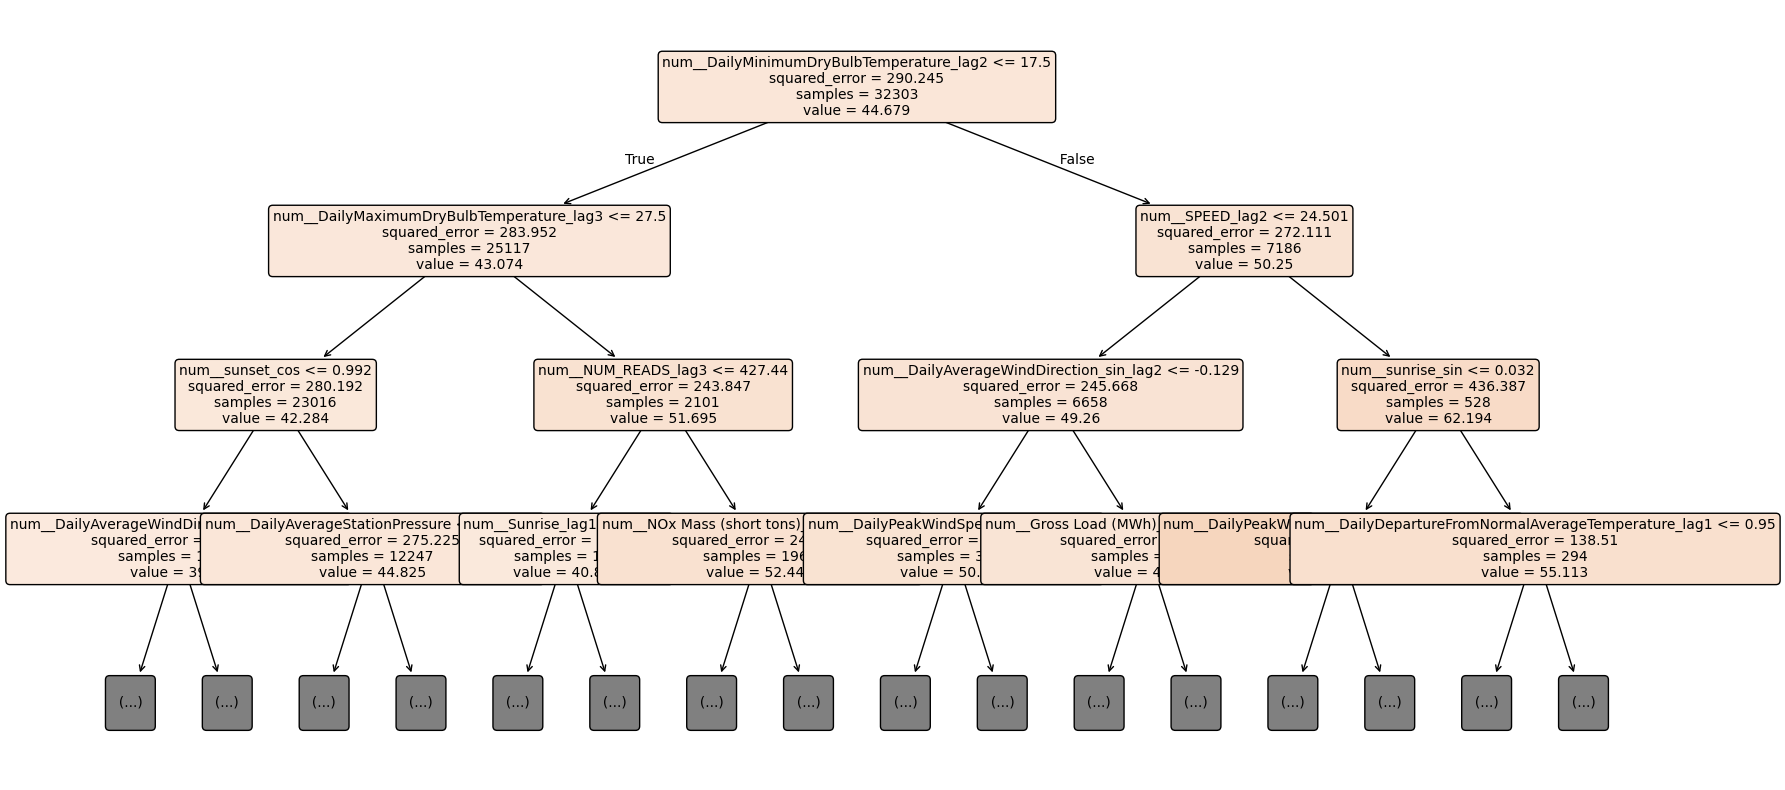

In [43]:
from sklearn.tree import export_graphviz, plot_tree

rf_aqi_model = random_forest_aqi[0].named_steps['model']
rf_aqi_pipe = random_forest_aqi[0]
tree = rf_aqi_model.estimators_[0]

plt.figure(figsize=(20,10))
plot_tree(
    tree, 
    feature_names=rf_aqi_pipe.named_steps['preprocess'].get_feature_names_out(), 
    filled=True, 
    rounded=True,
    max_depth=3,  # limit depth for readability
    fontsize=10
)
plt.show()

# Adding LASSO --> OLS Models with Summed Independent Variables:

In [44]:
data = totaldataframe

#Compare two and three way fixed effects 

# totaldataframe2 includes all the aq station dummies for the three way fixed effects operation;
# Use same LASSO vars for PM and AQI 

# Need number and capacity variables that include running totals sum of all previous amounts? 

totaldataframe['Number_total'] = totaldataframe['Number'].cumsum()
totaldataframe['Capacity_total'] = totaldataframe['Capacity'].cumsum()


In [45]:
#Re-running first LASSO model: 

#Adding number total and capacity total to lasso variables: 
xtotalnum = ['Number_total']
xtotalcap = ['Capacity_total']

x_pm_num_total = xmatrixpm + xtotalnum
x_pm_cap_total = xmatrixpm + xtotalcap
x_aqi_num_total = xmatrixaqi + xtotalnum
x_aqi_cap_total = xmatrixaqi + xtotalcap

# PM on lasso features + total generators overall:

PM_NUMTOT_2way = model_4_lasso_panel(totaldataframe, x_pm_num_total, y_pm, fe)
PM_NUMTOT_2way

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:817: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunrise_cos_lag1, sunrise_cos_lag2, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


Dep. Variable:,arithmetic_mean,R-squared:,0.1420
Estimator:,PanelOLS,R-squared (Between):,0.3016
No. Observations:,72978,R-squared (Within):,0.0581
Date:,"Thu, Apr 30 2026",R-squared (Overall):,0.0583
Time:,22:08:04,Log-likelihood,-2.315e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,754.48
Entities:,2,P-value,0.0000
Avg Obs:,3.649e+04,Distribution:,"F(16,72951)"
Min Obs:,3.575e+04,,
Max Obs:,3.723e+04,F-statistic (robust):,-5.001e+16


In [46]:
# PM on Capacity totals with lasso features 

PM_CAPTOT_2way = model_4_lasso_panel(totaldataframe, x_pm_cap_total, y_pm, fe)
PM_CAPTOT_2way



/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:817: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunrise_cos_lag1, sunrise_cos_lag2, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


Dep. Variable:,arithmetic_mean,R-squared:,0.1416
Estimator:,PanelOLS,R-squared (Between):,0.1315
No. Observations:,72978,R-squared (Within):,0.0809
Date:,"Thu, Apr 30 2026",R-squared (Overall):,0.0810
Time:,22:08:04,Log-likelihood,-2.316e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,752.11
Entities:,2,P-value,0.0000
Avg Obs:,3.649e+04,Distribution:,"F(16,72951)"
Min Obs:,3.575e+04,,
Max Obs:,3.723e+04,F-statistic (robust):,5.036e+16


In [47]:
# Trying with AQI as dependent variable: 

AQI_NUMTOT_2way = model_4_lasso_panel(totaldataframe, x_aqi_num_total, y_aqi, fe)
AQI_NUMTOT_2way

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:817: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunset_cos_lag3, sunrise_cos_lag1, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


Dep. Variable:,aqi,R-squared:,0.2638
Estimator:,PanelOLS,R-squared (Between):,0.6139
No. Observations:,72978,R-squared (Within):,0.2365
Date:,"Thu, Apr 30 2026",R-squared (Overall):,0.2378
Time:,22:08:05,Log-likelihood,-2.992e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,1633.4
Entities:,2,P-value,0.0000
Avg Obs:,3.649e+04,Distribution:,"F(16,72951)"
Min Obs:,3.575e+04,,
Max Obs:,3.723e+04,F-statistic (robust):,-5.955e+16


In [48]:
AQI_CAPTOT_2way = model_4_lasso_panel(totaldataframe, x_aqi_cap_total, y_aqi, fe)
AQI_CAPTOT_2way

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:817: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunset_cos_lag3, sunrise_cos_lag1, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


Dep. Variable:,aqi,R-squared:,0.2634
Estimator:,PanelOLS,R-squared (Between):,0.5565
No. Observations:,72978,R-squared (Within):,0.2479
Date:,"Thu, Apr 30 2026",R-squared (Overall):,0.2489
Time:,22:08:05,Log-likelihood,-2.992e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,1630.6
Entities:,2,P-value,0.0000
Avg Obs:,3.649e+04,Distribution:,"F(16,72951)"
Min Obs:,3.575e+04,,
Max Obs:,3.723e+04,F-statistic (robust):,2.151e+18


In [49]:
# Season fixed effects? 
# This eliminates seasonal factors that might correlate with both air quality and renewable installation: for instance if more renewable installments are done 
# During the winter when there is already less air pollution in the atmosphere 

# def assign_season(month):
#     if month in [12, 1, 2]:
#         return 'Winter'
#     elif month in [3, 4, 5]:
#         return 'Spring'
#     elif month in [6, 7, 8]:
#         return 'Summer'
#     else:
#         return 'Fall'

# totaldataframe['season'] = totaldataframe['MONTH'].apply(assign_season)
# seasondummies = pd.get_dummies(totaldataframe, columns=['season'], prefix= 'season', drop_first=True)
# totaldataframe_season = pd.concat([totaldataframe, seasondummies], axis=1)

# This didn't work

# Month instead of Year fixed effects: 


In [50]:
from Analysis import model_5_oneway_fe

In [57]:
month = ['CLIMATE_STATION_NAME','MONTH']

In [58]:
PM_NUM_MONTH = model_5_oneway_fe(totaldataframe, x_pm_num, y_pm, month)
PM_NUM_MONTH

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:347: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunrise_cos_lag1, sunrise_cos_lag2, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


Dep. Variable:,arithmetic_mean,R-squared:,0.1357
Estimator:,PanelOLS,R-squared (Between):,0.5844
No. Observations:,72978,R-squared (Within):,0.1329
Date:,"Thu, Apr 30 2026",R-squared (Overall):,0.1333
Time:,22:10:55,Log-likelihood,-2.313e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,716.04
Entities:,2,P-value,0.0000
Avg Obs:,3.649e+04,Distribution:,"F(16,72950)"
Min Obs:,3.575e+04,,
Max Obs:,3.723e+04,F-statistic (robust):,1.239e+16


In [60]:
PM_CAP_MONTH = model_5_oneway_fe(totaldataframe, x_pm_cap, y_pm,month)
PM_CAP_MONTH

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:347: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunrise_cos_lag1, sunrise_cos_lag2, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


Dep. Variable:,arithmetic_mean,R-squared:,0.1358
Estimator:,PanelOLS,R-squared (Between):,0.5818
No. Observations:,72978,R-squared (Within):,0.1330
Date:,"Thu, Apr 30 2026",R-squared (Overall):,0.1334
Time:,22:14:50,Log-likelihood,-2.313e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,716.74
Entities:,2,P-value,0.0000
Avg Obs:,3.649e+04,Distribution:,"F(16,72950)"
Min Obs:,3.575e+04,,
Max Obs:,3.723e+04,F-statistic (robust):,-4.476e+16


## Re-running previous models with month:

In [61]:
fe3 = ['CLIMATE_STATION_NAME', 'MONTH']

In [62]:
#PM on number with station and month fe
PM_NUM_MONTH2way = model_4_lasso_panel(totaldataframe,x_pm_num, y_pm, fe3)
PM_NUM_MONTH2way

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:817: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunrise_cos_lag1, sunrise_cos_lag2, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


Dep. Variable:,arithmetic_mean,R-squared:,0.1356
Estimator:,PanelOLS,R-squared (Between):,-3.4659
No. Observations:,72978,R-squared (Within):,0.1287
Date:,"Thu, Apr 30 2026",R-squared (Overall):,0.1254
Time:,22:21:49,Log-likelihood,-2.312e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,715.13
Entities:,2,P-value,0.0000
Avg Obs:,3.649e+04,Distribution:,"F(16,72949)"
Min Obs:,3.575e+04,,
Max Obs:,3.723e+04,F-statistic (robust):,2.146e+18


In [63]:
#PM on number with station and month fe
PM_CAP_MONTH2way = model_4_lasso_panel(totaldataframe,x_pm_cap, y_pm, fe3)
PM_CAP_MONTH2way

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:817: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunrise_cos_lag1, sunrise_cos_lag2, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


Dep. Variable:,arithmetic_mean,R-squared:,0.1357
Estimator:,PanelOLS,R-squared (Between):,-3.4840
No. Observations:,72978,R-squared (Within):,0.1286
Date:,"Thu, Apr 30 2026",R-squared (Overall):,0.1253
Time:,22:22:39,Log-likelihood,-2.312e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,715.85
Entities:,2,P-value,0.0000
Avg Obs:,3.649e+04,Distribution:,"F(16,72949)"
Min Obs:,3.575e+04,,
Max Obs:,3.723e+04,F-statistic (robust):,1.336e+17


In [64]:
#AQI on num with month 2way

AQI_NUM_MONTH = model_4_lasso_panel(totaldataframe,x_aqi_num, y_aqi, fe3)
AQI_NUM_MONTH

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:817: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunset_cos_lag3, sunrise_cos_lag1, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


Dep. Variable:,aqi,R-squared:,0.2529
Estimator:,PanelOLS,R-squared (Between):,0.0574
No. Observations:,72978,R-squared (Within):,0.2577
Date:,"Thu, Apr 30 2026",R-squared (Overall):,0.2570
Time:,22:23:30,Log-likelihood,-2.987e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,1543.0
Entities:,2,P-value,0.0000
Avg Obs:,3.649e+04,Distribution:,"F(16,72949)"
Min Obs:,3.575e+04,,
Max Obs:,3.723e+04,F-statistic (robust):,1.178e+17


In [65]:
# AQI on Cap with month 2 way fe:

AQI_CAP_MONTH = model_4_lasso_panel(totaldataframe, x_aqi_cap, y_aqi, fe3)
AQI_CAP_MONTH

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:817: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunset_cos_lag3, sunrise_cos_lag1, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


Dep. Variable:,aqi,R-squared:,0.2531
Estimator:,PanelOLS,R-squared (Between):,0.0501
No. Observations:,72978,R-squared (Within):,0.2576
Date:,"Thu, Apr 30 2026",R-squared (Overall):,0.2569
Time:,22:24:35,Log-likelihood,-2.987e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,1545.1
Entities:,2,P-value,0.0000
Avg Obs:,3.649e+04,Distribution:,"F(16,72949)"
Min Obs:,3.575e+04,,
Max Obs:,3.723e+04,F-statistic (robust):,-5.538e+18


In [66]:
# AQI num with 3 way fe:

AQI_NUM_3way = model_4_lasso_panel(totaldataframe2, x_aqi_num_aq, y_aqi, fe)
AQI_NUM_3way

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:817: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunrise_cos_lag1, sunset_cos, AQ_STATION_NAME_REGIONAL OFFICE BUILDING, AQ_STATION_NAME_VILLAGE HALL, AQ_STATION_NAME_WASHINGTON HS

  results = model.fit(cov_type='clustered', cluster_entity=True)


Dep. Variable:,aqi,R-squared:,0.2765
Estimator:,PanelOLS,R-squared (Between):,-5.149e+04
No. Observations:,72978,R-squared (Within):,0.2746
Date:,"Thu, Apr 30 2026",R-squared (Overall):,-171.70
Time:,22:27:28,Log-likelihood,-2.985e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,1115.3
Entities:,2,P-value,0.0000
Avg Obs:,3.649e+04,Distribution:,"F(25,72942)"
Min Obs:,3.575e+04,,
Max Obs:,3.723e+04,F-statistic (robust):,-6.395e+15


In [67]:
#AQI capacity 3 way fe:

AQI_CAP_3way = model_4_lasso_panel(totaldataframe2, x_aqi_cap_aq, y_aqi, fe)
AQI_CAP_3way



/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:817: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunrise_cos_lag1, sunset_cos, AQ_STATION_NAME_REGIONAL OFFICE BUILDING, AQ_STATION_NAME_VILLAGE HALL, AQ_STATION_NAME_WASHINGTON HS

  results = model.fit(cov_type='clustered', cluster_entity=True)


Dep. Variable:,aqi,R-squared:,0.2766
Estimator:,PanelOLS,R-squared (Between):,-5.161e+04
No. Observations:,72978,R-squared (Within):,0.2748
Date:,"Thu, Apr 30 2026",R-squared (Overall):,-172.09
Time:,22:29:20,Log-likelihood,-2.985e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,1115.8
Entities:,2,P-value,0.0000
Avg Obs:,3.649e+04,Distribution:,"F(25,72942)"
Min Obs:,3.575e+04,,
Max Obs:,3.723e+04,F-statistic (robust):,-3.172e+17


In [97]:
# Using cumulative variables and month fixed effects: 
AQI_NUMTOT_MONTH = model_4_lasso_panel(totaldataframe, x_aqi_num_total, y_aqi, fe3)
AQI_NUMTOT_MONTH

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:817: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunset_cos_lag3, sunrise_cos_lag1, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


Dep. Variable:,aqi,R-squared:,0.2534
Estimator:,PanelOLS,R-squared (Between):,-0.0364
No. Observations:,72978,R-squared (Within):,0.2564
Date:,"Fri, May 01 2026",R-squared (Overall):,0.2554
Time:,16:52:23,Log-likelihood,-2.987e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,1547.8
Entities:,2,P-value,0.0000
Avg Obs:,3.649e+04,Distribution:,"F(16,72949)"
Min Obs:,3.575e+04,,
Max Obs:,3.723e+04,F-statistic (robust):,-2.154e+18


In [98]:
AQI_CAPTOT_MONTH = model_4_lasso_panel(totaldataframe, x_aqi_cap_total, y_aqi, fe3)
AQI_CAPTOT_MONTH

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:817: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunset_cos_lag3, sunrise_cos_lag1, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


Dep. Variable:,aqi,R-squared:,0.2536
Estimator:,PanelOLS,R-squared (Between):,-0.0438
No. Observations:,72978,R-squared (Within):,0.2565
Date:,"Fri, May 01 2026",R-squared (Overall):,0.2555
Time:,16:53:10,Log-likelihood,-2.987e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,1549.3
Entities:,2,P-value,0.0000
Avg Obs:,3.649e+04,Distribution:,"F(16,72949)"
Min Obs:,3.575e+04,,
Max Obs:,3.723e+04,F-statistic (robust):,2.058e+18


In [99]:
# Totals and month fixed effects for PM 2.5:
PM_NUMTOT_MONTH = model_4_lasso_panel(totaldataframe, x_pm_num_total, y_pm, fe3)
PM_NUMTOT_MONTH

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:817: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunrise_cos_lag1, sunrise_cos_lag2, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


Dep. Variable:,arithmetic_mean,R-squared:,0.1375
Estimator:,PanelOLS,R-squared (Between):,-4.0312
No. Observations:,72978,R-squared (Within):,0.1294
Date:,"Fri, May 01 2026",R-squared (Overall):,0.1257
Time:,17:33:22,Log-likelihood,-2.312e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,726.55
Entities:,2,P-value,0.0000
Avg Obs:,3.649e+04,Distribution:,"F(16,72949)"
Min Obs:,3.575e+04,,
Max Obs:,3.723e+04,F-statistic (robust):,3.481e+17


In [100]:
# Totals Capacity and month fixed effects for PM 2.5:
PM_CAPTOT_MONTH = model_4_lasso_panel(totaldataframe, x_pm_cap_total, y_pm, fe3)
PM_CAPTOT_MONTH

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:817: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunrise_cos_lag1, sunrise_cos_lag2, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


Dep. Variable:,arithmetic_mean,R-squared:,0.1377
Estimator:,PanelOLS,R-squared (Between):,-4.0556
No. Observations:,72978,R-squared (Within):,0.1298
Date:,"Fri, May 01 2026",R-squared (Overall):,0.1261
Time:,17:33:57,Log-likelihood,-2.311e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,728.37
Entities:,2,P-value,0.0000
Avg Obs:,3.649e+04,Distribution:,"F(16,72949)"
Min Obs:,3.575e+04,,
Max Obs:,3.723e+04,F-statistic (robust):,8.276e+16


# Tables for Cumulative Fixed Effects 

In [ ]:
#Tables for Cumalitve independent vars:
m1 = PM_NUMTOT_2way
m2 = PM_CAPTOT_2way

removal_list = ["CO2 Mass (short tons)_lag3", "CO2 Mass (short tons)", 'Number_total']
covariates_list = list(filter(lambda x: x not in removal_list, sig_vars(m1)))

setup3 = Stargazer([m1,m2])
setup3.title("Relationships between PM 2.5 and Renewable Generators: Cumalative Generator Numbers vs. Capacities (LASSO to Panel OLS)")
setup3.custom_columns(["Cumulative Generators (N)", "Cumulative Capacity (MW)"], [1, 1])
setup3.dependent_variable_name("Average PM 2.5 (micro grams/m^3)")
setup3.covariate_order(['Capacity_total', 'Number_total'] + covariates_list)  # Only include significant variables in the table
setup3.rename_covariates(rename_dict)

setup3.significance_levels([0.1, 0.05, 0.01])   # * p<0.1, ** p<0.05, *** p<0.01
setup3.show_degrees_of_freedom(False)

# Ellipsis for omitted variables:
setup3.add_line("...", ["...", "..."])
#Adding fixed effects indicator: 
setup3.add_line(
    "Fixed effects",
    ["Yes", "Yes"],
    LineLocation.FOOTER_TOP,
)
setup3.add_line(
    "Standard errors",
    ["Robust (HC1)", "Robust (HC1)"],
    LineLocation.FOOTER_TOP,
)
setup3.add_custom_notes([
    "Heteroskedasticity-robust standard errors in parentheses.",
    "Fixed effects for Climate Station and Year included",
])

setup3

In [ ]:
# Table for cumulative num and cap with y= AQI:
#Tables for Cumalitve independent vars:
m1 = AQI_NUMTOT_2way
m2 = AQI_CAPTOT_2way

removal_list = ["CO2 Mass (short tons)_lag3", "CO2 Mass (short tons)", 'Number_total']
covariates_list = list(filter(lambda x: x not in removal_list, sig_vars(m1)))

setup4 = Stargazer([m1,m2])
setup4.title("Relationships between AQI and Renewable Generators: Cumalative Generator Numbers vs. Capacities (LASSO to Panel OLS)")
setup4.custom_columns(["Cumulative Generators (N)", "Cumulative Capacity (MW)"], [1, 1])
setup4.dependent_variable_name("Average AQI")
setup4.covariate_order(['Capacity_total', 'Number_total'] + covariates_list)  # Only include significant variables in the table
setup4.rename_covariates(rename_dict)

setup4.significance_levels([0.1, 0.05, 0.01])   # * p<0.1, ** p<0.05, *** p<0.01
setup4.show_degrees_of_freedom(False)

# Ellipsis for omitted variables:
setup4.add_line("...", ["...", "..."])
#Adding fixed effects indicator: 
setup4.add_line(
    "Fixed effects",
    ["Yes", "Yes"],
    LineLocation.FOOTER_TOP,
)
setup4.add_line(
    "Standard errors",
    ["Robust (HC1)", "Robust (HC1)"],
    LineLocation.FOOTER_TOP,
)
setup4.add_custom_notes([
    "Heteroskedasticity-robust standard errors in parentheses.",
    "Fixed effects for Climate Station and Year included",
])

setup4

# Tables for Month Fixed Effects 

In [ ]:
# PM with the 2 way month effects 
#Tables for Cumalitve independent vars:
m1 = PM_NUM_MONTH2way
m2 = PM_CAP_MONTH2way

removal_list = ["CO2 Mass (short tons)_lag3", "CO2 Mass (short tons)", "Number"]
covariates_list = list(filter(lambda x: x not in removal_list, sig_vars(m1)))

setup5 = Stargazer([m1,m2])
setup5.title("Average PM 2.5 and Renewable Generators: Generator Numbers vs. Capacities (Station and Month FE)")
setup5.custom_columns(["Number of Generators (N)", " Capacity (MW)"], [1, 1])
setup5.dependent_variable_name("Average PM 2.5 (micro grams/m^3)")
setup5.covariate_order(['Capacity', 'Number'] + covariates_list)  # Only include significant variables in the table
setup5.rename_covariates(rename_dict)

setup5.significance_levels([0.1, 0.05, 0.01])   # * p<0.1, ** p<0.05, *** p<0.01
setup5.show_degrees_of_freedom(False)

# Ellipsis for omitted variables:
setup5.add_line("...", ["...", "..."])
#Adding fixed effects indicator: 
setup5.add_line(
    "Climate and Month Fixed effects",
    ["Yes", "Yes"],
    LineLocation.FOOTER_TOP,
)
setup5.add_line(
    "Standard errors",
    ["Robust (HC1)", "Robust (HC1)"],
    LineLocation.FOOTER_TOP,
)
setup5.add_custom_notes([
    "Heteroskedasticity-robust standard errors in parentheses.",
    "Fixed effects for Climate Station and Month included",
])

setup5


In [ ]:
m1 = OLS_AQI_NUM
m2 = OLS_AQI_CAP
m3 = OLS_AQI_NUM_AQ
m4 = OLS_AQI_CAP_AQ

#Shortening the list of covariates:
removal_list = ["CO2 Mass (short tons)_lag3", "CO2 Mass (short tons)", "DailyMinimumDryBulbTemperature", "Daily Peak Wind Direction (Sine)",
                "AQlongitude", "Daily Sustained Wind Direction (Cosine)"]
covariates_list = list(filter(lambda x: x not in removal_list, sig_vars(m1)))
# covariates_list = sig_vars(m1)

setup6 = Stargazer([m1,m2,m3,m4])
setup6.title("Relationships between Average AQI and Renewable Generators: (LASSO to Panel OLS)")

setup6.custom_columns(["Number", "Capacity", "Number 3-Way", "Capacity 3-Way"], [1,1,1,1])
setup6.dependent_variable_name("Average AQI")

setup6.covariate_order(['Capacity'] + covariates_list)  # Only include significant variables in the table
setup6.rename_covariates(rename_dict)
setup6.significance_levels([0.1, 0.05, 0.01])   # * p<0.1, ** p<0.05, *** p<0.01
setup6.show_degrees_of_freedom(False)

# Ellipsis for omitted variables:
setup6.add_line("...", ["...", "...", "...", "..."])

#Adding fixed effects indicator: 
setup6.add_line(
    "Two-Way Fixed Effects",
    ["Yes", "Yes","No","No"],
    LineLocation.FOOTER_TOP,
)
setup6.add_line(
    "Three-Way Fixed Effects",
    ['No','No','Yes','Yes'],
    LineLocation.FOOTER_TOP,
)
setup6.add_line(
    "Standard errors",
    ["Robust (HC1)", "Robust (HC1)", "Robust (HC1)", "Robust (HC1)"],
    LineLocation.FOOTER_TOP,
)
setup6.add_custom_notes([
    "Heteroskedasticity-robust standard errors in parentheses.",
    "Two-Way Fixed Effects for Climate Station and Month included",
    "Three-Way Fixed Effects for Climate Station, Month, and AQ Station included in Columns 3 and 4",
])

setup6